Two-stage pipeline:
- **Stage 1**: Identify daily market regime (Bullish / Bearish / High-Volatility) from aggregated S&P 500 signals using LR, RF, LightGBM, LSTM.
- **Stage 2**: Stock-level Buy / Hold / Sell classification enriched with Stage 1 regime predictions.

Data source: `data/features/sp500_panel_with_features.csv`

In [29]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit

import lightgbm as lgb

import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('models/trained', exist_ok=True)
os.makedirs('plots/trained', exist_ok=True)

In [2]:
df = pd.read_csv('data/features/sp500_panel_with_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Encoded_Ticker', 'Date']).reset_index(drop=True)

FEATURE_COLS = [
    'Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm', # Momentum
    'ATR_Pct', 'HL_range', # Volatility
    'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct', # Trend
    'Encoded_Ticker' # Identity
]

print(f'Loaded: {len(df):,} rows | {df["Encoded_Ticker"].nunique()} tickers')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded: 1,193,500 rows | 499 tickers
Date range: 2016-03-09 → 2025-12-18
Columns: ['Date', 'Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm', 'ATR_Pct', 'HL_range', 'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct', 'Encoded_Ticker', 'y_return']


,Date,Ret_Lag1,Ret_Lag2,RSI,MACD_Norm,ATR_Pct,HL_range,Price_vs_SMA50,Momentum_Deviation,BB_Pct,Encoded_Ticker,y_return
0,2016-03-09,0.001050,-0.033984,57.966095,0.007981,0.020606,0.011540,1.003275,-0.018230,0.596292,0,-0.003934
1,2016-03-10,-0.003934,0.001050,54.655204,0.006779,0.020951,0.023433,1.001271,-0.015909,0.541852,0,0.032912
2,2016-03-11,0.032912,-0.003934,59.287856,0.008094,0.021267,0.024216,1.035871,0.017059,0.845679,0,-0.005353
3,2016-03-14,-0.005353,0.032912,65.920810,0.008822,0.020905,0.019477,1.031980,0.013770,0.771143,0,-0.018708
4,2016-03-15,-0.018708,-0.005353,56.500849,0.007913,0.021136,0.016453,1.014563,-0.006229,0.527829,0,0.018021


---
## 2. Define Labels

### 2A. Stage 1 — Market Regime Labels
Since the raw index is not in the dataset, we construct a daily **market proxy** by computing cross-sectional mean returns across all tickers for each date. Regime is then defined via rolling statistics.

In [3]:
# ── Market proxy: equal-weighted daily return across all tickers ──
market_daily = (
    df.groupby('Date')['Ret_Lag1']
    .mean()
    .reset_index()
    .rename(columns={'Ret_Lag1': 'market_return'})
    .sort_values('Date')
)

# Rolling stats (20-day window)
WINDOW = 20
market_daily['rolling_ret'] = market_daily['market_return'].rolling(WINDOW).mean()
market_daily['rolling_vol'] = market_daily['market_return'].rolling(WINDOW).std()

# Drop NaNs from the rolling warm-up period
market_daily.dropna(inplace=True)

# ── Regime thresholds (percentile-based, data-driven) ──
ret_hi = market_daily['rolling_ret'].quantile(0.60) # top 40% → Bullish
ret_lo = market_daily['rolling_ret'].quantile(0.40) # bottom 40% → Bearish
vol_hi = market_daily['rolling_vol'].quantile(0.70) # top 30% vol → High-Vol

def assign_regime(row):
    if row['rolling_vol'] >= vol_hi: return 2  # High-Volatility (overrides direction)
    elif row['rolling_ret'] >= ret_hi: return 0  # Bullish
    elif row['rolling_ret'] <= ret_lo: return 1  # Bearish
    else: return 0  # Default to Bullish if neutral — adjust if needed

market_daily['regime'] = market_daily.apply(assign_regime, axis=1)

REGIME_NAMES = {0: 'Bullish', 1: 'Bearish', 2: 'High-Volatility'}
print('Regime distribution:')
print(market_daily['regime'].map(REGIME_NAMES).value_counts())

market_daily[['Date', 'market_return', 'rolling_ret', 'rolling_vol', 'regime']].tail()

Regime distribution:
regime
Bullish            1140
High-Volatility     733
Bearish             569
Name: count, dtype: int64


,Date,market_return,rolling_ret,rolling_vol,regime
2456,2025-12-12,-0.005442,0.001529,0.008541,0
2457,2025-12-15,0.001028,0.001726,0.008478,0
2458,2025-12-16,-0.006803,0.002053,0.007977,0
2459,2025-12-17,-0.002309,0.001941,0.008024,0
2460,2025-12-18,0.001728,0.002176,0.007941,0


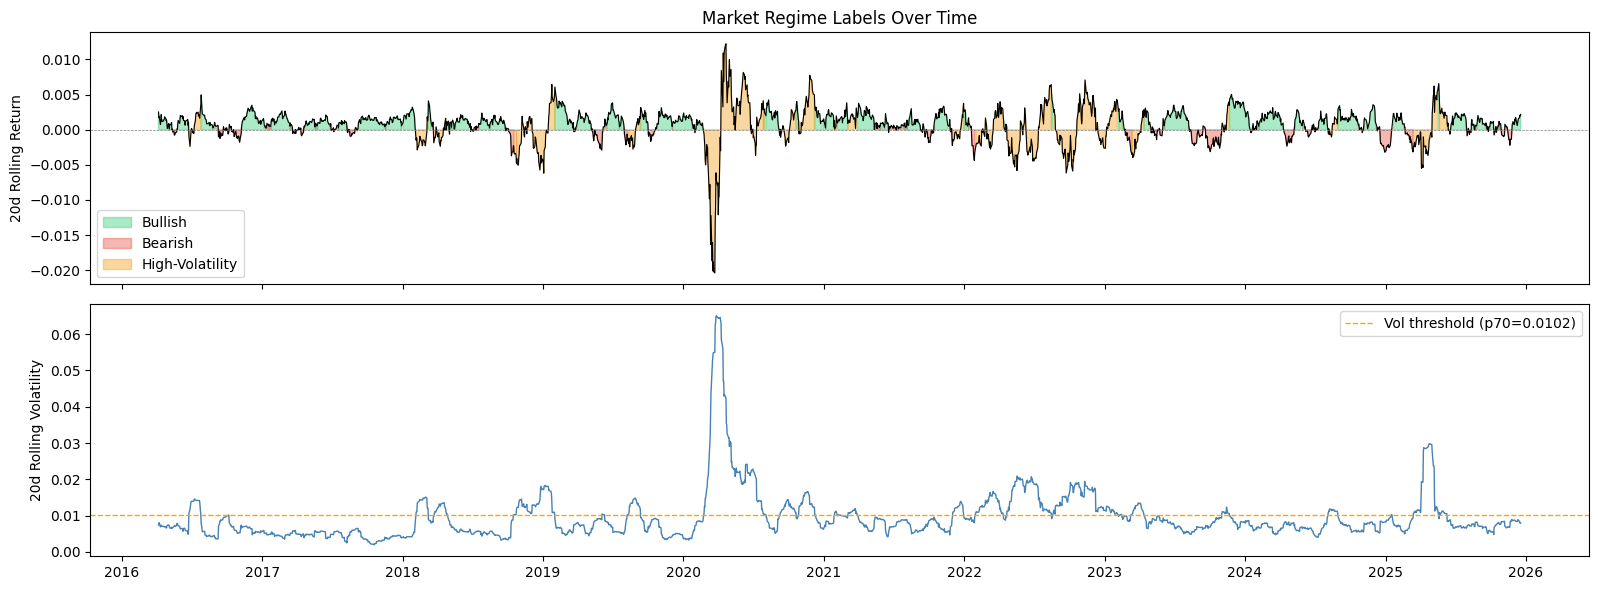

In [4]:
# ── Visualize regime timeline ──
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

colors = {0: '#2ecc71', 1: '#e74c3c', 2: '#f39c12'}
for regime, name in REGIME_NAMES.items():
    mask = market_daily['regime'] == regime
    axes[0].fill_between(market_daily['Date'], market_daily['rolling_ret'],
                         where=mask, alpha=0.4, color=colors[regime], label=name)
axes[0].plot(market_daily['Date'], market_daily['rolling_ret'], color='black', lw=0.8)
axes[0].axhline(0, color='grey', lw=0.5, linestyle='--')
axes[0].set_ylabel('20d Rolling Return')
axes[0].legend()
axes[0].set_title('Market Regime Labels Over Time')

axes[1].plot(market_daily['Date'], market_daily['rolling_vol'], color='steelblue', lw=1)
axes[1].axhline(vol_hi, color='orange', linestyle='--', lw=1, label=f'Vol threshold (p70={vol_hi:.4f})')
axes[1].set_ylabel('20d Rolling Volatility')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/trained/regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

### 2B. Stage 2 — Stock-Level Buy / Hold / Sell Labels
Labels are defined per-ticker using tercile splits on `y_return`, so thresholds are relative to each stock's own return distribution rather than an absolute threshold.

In [5]:
# Tertile-based labeling (per-ticker to be scale-invariant)
def label_signal(series):
    low  = series.quantile(0.33)
    high = series.quantile(0.67)
    
    if low == high:
        median = series.median()
        return pd.Series(
            np.where(series < median, 0, np.where(series > median, 2, 1)),
            index=series.index
        )
    
    return pd.cut(series, bins=[-np.inf, low, high, np.inf],
                  labels=[0, 1, 2])

df['signal'] = df.groupby('Encoded_Ticker')['y_return'].transform(label_signal).astype(int)

SIGNAL_NAMES = {0: 'Sell', 1: 'Hold', 2: 'Buy'}
print('Signal distribution (Stage 2 labels):')
print(df['signal'].map(SIGNAL_NAMES).value_counts())

Signal distribution (Stage 2 labels):
signal
Hold    406301
Buy     393612
Sell    393587
Name: count, dtype: int64


---
## 3. Stage 1 — Market Regime Classification

### 3A. Prepare Stage 1 Dataset

Stage 1 operates at the **market level** (one row per date). Features are cross-sectional means of the stationary engineered features — no raw price levels.

In [6]:
S1_FEATURES = ['Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm',
               'ATR_Pct', 'HL_range', 'Price_vs_SMA50',
               'Momentum_Deviation', 'BB_Pct']

# Cross-sectional mean per date → market-level signal
stage1_df = (
    df.groupby('Date')[S1_FEATURES]
    .mean()
    .reset_index()
    .sort_values('Date')
)

# Merge regime labels
stage1_df = stage1_df.merge(market_daily[['Date', 'regime']], on='Date', how='inner')
stage1_df.dropna(inplace=True)
stage1_df.reset_index(drop=True, inplace=True)

print(f'Stage 1 dataset: {stage1_df.shape}')
stage1_df.head()

Stage 1 dataset: (2442, 11)


,Date,Ret_Lag1,Ret_Lag2,RSI,MACD_Norm,ATR_Pct,HL_range,Price_vs_SMA50,Momentum_Deviation,BB_Pct,regime
0,2016-04-06,0.010556,-0.010916,58.192828,0.014801,0.021377,0.022057,1.061781,0.000575,0.633705,0
1,2016-04-07,-0.011427,0.010533,50.385930,0.013507,0.021373,0.021421,1.047724,-0.008525,0.471505,0
2,2016-04-08,0.004080,-0.011427,50.333911,0.012435,0.021112,0.018875,1.049738,-0.001791,0.511665,0
3,2016-04-11,-0.002419,0.004080,49.670430,0.011335,0.021209,0.019125,1.044971,-0.002130,0.472507,0
4,2016-04-12,0.008380,-0.002419,52.974539,0.010890,0.021101,0.019866,1.051865,0.004451,0.576308,0


### 3B. Chronological Train/Test Split

In [7]:
split_date_s1 = stage1_df['Date'].quantile(0.8)

train_s1 = stage1_df[stage1_df['Date'] <= split_date_s1]
test_s1  = stage1_df[stage1_df['Date'] >  split_date_s1]

X_train_s1 = train_s1[S1_FEATURES].values
y_train_s1 = train_s1['regime'].values
X_test_s1  = test_s1[S1_FEATURES].values
y_test_s1  = test_s1['regime'].values

# Scale
scaler_s1 = StandardScaler()
X_train_s1_sc = scaler_s1.fit_transform(X_train_s1)
X_test_s1_sc  = scaler_s1.transform(X_test_s1)

print(f'Stage 1 Train: {len(train_s1)} dates | Test: {len(test_s1)} dates')
print(f'Split date: {split_date_s1.date()}')

Stage 1 Train: 1953 dates | Test: 489 dates
Split date: 2024-01-08


### 3C. Model 1 — Logistic Regression (Baseline)

In [8]:
lr_s1 = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr_s1.fit(X_train_s1_sc, y_train_s1)

y_pred_lr_s1 = lr_s1.predict(X_test_s1_sc)
print('=== Stage 1 — Logistic Regression ===')
print(classification_report(y_test_s1, y_pred_lr_s1,
      target_names=list(REGIME_NAMES.values())))

=== Stage 1 — Logistic Regression ===
                 precision    recall  f1-score   support

        Bullish       0.82      0.65      0.72       248
        Bearish       0.76      0.56      0.64       162
High-Volatility       0.32      0.72      0.45        79

       accuracy                           0.63       489
      macro avg       0.64      0.64      0.60       489
   weighted avg       0.72      0.63      0.65       489



### 3D. Model 2 — Random Forest

In [9]:
rf_s1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_s1.fit(X_train_s1_sc, y_train_s1)

y_pred_rf_s1 = rf_s1.predict(X_test_s1_sc)
print('=== Stage 1 — Random Forest ===')
print(classification_report(y_test_s1, y_pred_rf_s1,
      target_names=list(REGIME_NAMES.values())))

=== Stage 1 — Random Forest ===
                 precision    recall  f1-score   support

        Bullish       0.80      0.70      0.75       248
        Bearish       0.74      0.57      0.64       162
High-Volatility       0.39      0.72      0.50        79

       accuracy                           0.66       489
      macro avg       0.64      0.66      0.63       489
   weighted avg       0.71      0.66      0.67       489



### 3E. Model 3 — LightGBM

In [10]:
lgb_s1 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    min_child_samples=20,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_s1.fit(
    X_train_s1_sc, y_train_s1,
    eval_set=[(X_test_s1_sc, y_test_s1)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

y_pred_lgb_s1 = lgb_s1.predict(X_test_s1_sc)
print('=== Stage 1 — LightGBM ===')
print(classification_report(y_test_s1, y_pred_lgb_s1,
      target_names=list(REGIME_NAMES.values())))

=== Stage 1 — LightGBM ===
                 precision    recall  f1-score   support

        Bullish       0.81      0.73      0.77       248
        Bearish       0.76      0.64      0.70       162
High-Volatility       0.44      0.72      0.55        79

       accuracy                           0.70       489
      macro avg       0.67      0.70      0.67       489
   weighted avg       0.73      0.70      0.71       489



### 3F. Stage 1 — Comparative Evaluation

In [11]:
s1_results = {
    'Logistic Regression': (y_test_s1, y_pred_lr_s1),
    'Random Forest': (y_test_s1, y_pred_rf_s1),
    'LightGBM': (y_test_s1, y_pred_lgb_s1),
}

summary_s1 = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': accuracy_score(yt, yp),
        'Macro F1':  f1_score(yt, yp, average='macro'),
        'Weighted F1': f1_score(yt, yp, average='weighted'),
    }
    for name, (yt, yp) in s1_results.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('=== Stage 1 Model Comparison ===')
print(summary_s1.to_string(index=False))

=== Stage 1 Model Comparison ===
              Model  Accuracy  Macro F1  Weighted F1
           LightGBM  0.697342  0.669021     0.707043
      Random Forest  0.660532  0.631521     0.673364
Logistic Regression  0.627812  0.604088     0.651539


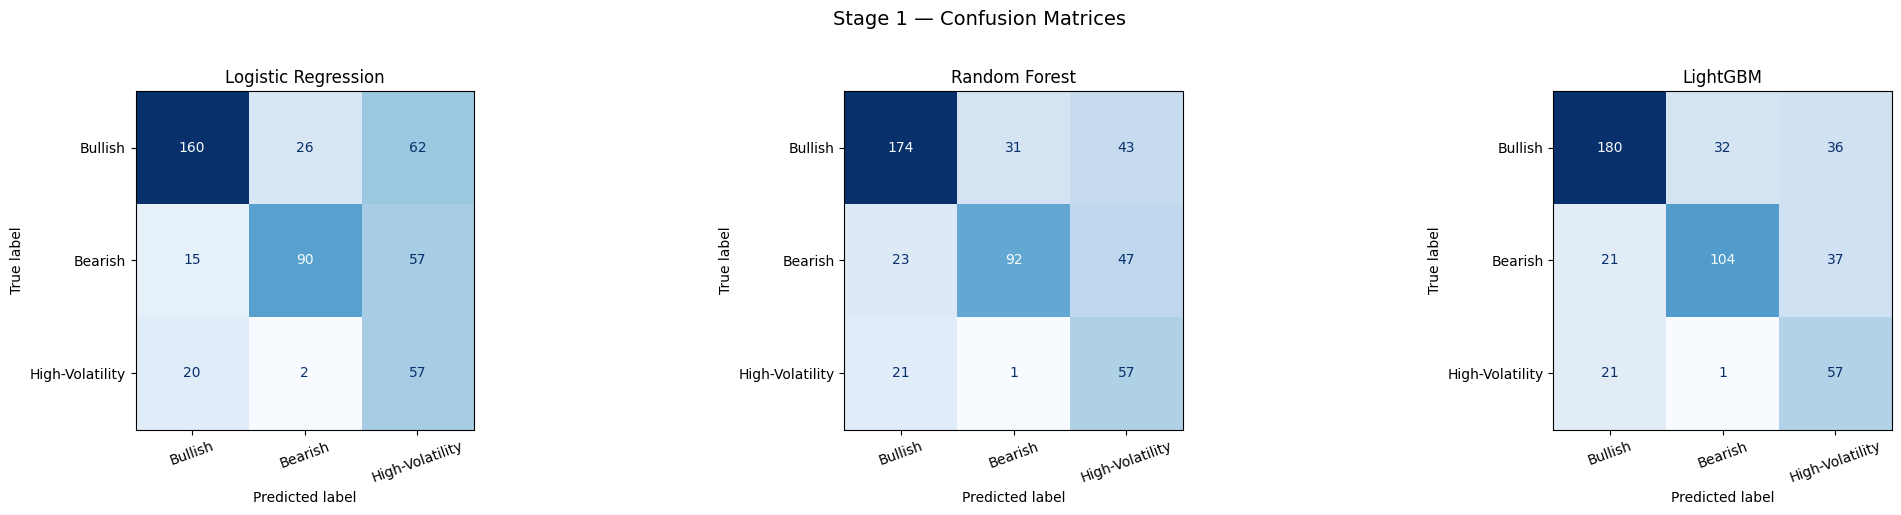

In [12]:
# ── Confusion matrices ──
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for ax, (name, (yt, yp)) in zip(axes, s1_results.items()):
    cm = confusion_matrix(yt, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(REGIME_NAMES.values()))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Stage 1 — Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/trained/s1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 3H. Generate Regime Predictions for All Dates

We use the **best Stage 1 model** (by Macro F1) to produce regime predictions for every date in the dataset. These predictions are then merged back into the stock-level dataframe as a feature for Stage 2.

In [13]:
BEST_S1_MODEL = lgb_s1 # since it had the best macro f1 score

X_all_scaled = scaler_s1.transform(stage1_df[S1_FEATURES].values)
stage1_df['regime_pred'] = BEST_S1_MODEL.predict(X_all_scaled)

df = df.merge(stage1_df[['Date', 'regime_pred']], on='Date', how='left')
df['regime_pred'] = df['regime_pred'].ffill().bfill().astype(int)

print(f'Regime predictions merged. Null count: {df["regime_pred"].isnull().sum()}')
df[['Date', 'Encoded_Ticker', 'regime_pred', 'signal']].head(10)

Regime predictions merged. Null count: 0


,Date,Encoded_Ticker,regime_pred,signal
0,2016-03-09,0,0,1
1,2016-03-10,0,0,2
2,2016-03-11,0,0,0
3,2016-03-14,0,0,0
4,2016-03-15,0,0,2
5,2016-03-16,0,0,2
6,2016-03-17,0,0,2
7,2016-03-18,0,0,0
8,2016-03-21,0,0,1
9,2016-03-22,0,0,0


In [14]:
df.to_csv("data/model/regime_pred.csv", index=False)

---
## 4. Stage 2 — Stock-Level Buy / Hold / Sell Classification

### 4A. Prepare Stage 2 Dataset

In [15]:
# Stage 2 features: stock features + regime signal from Stage 1
S2_FEATURES_BASE = [
    'Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm',
    'ATR_Pct', 'HL_range',
    'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct',
    'Encoded_Ticker'
]

S2_FEATURES_REGIME = S2_FEATURES_BASE + ['regime_pred']

df_s2 = df[S2_FEATURES_REGIME + ['Date', 'signal', 'y_return']].dropna()
df_s2 = df_s2.sort_values('Date').reset_index(drop=True)

print(f'Stage 2 dataset: {df_s2.shape}')
print(f'Signal distribution: {df_s2["signal"].value_counts().to_dict()}')

Stage 2 dataset: (1193500, 14)
Signal distribution: {1: 406301, 2: 393612, 0: 393587}


### 4B. Chronological Train/Test Split

In [16]:
split_date_s2 = df_s2['Date'].quantile(0.8)

train_s2 = df_s2[df_s2['Date'] <= split_date_s2]
test_s2  = df_s2[df_s2['Date'] >  split_date_s2]

X_train_s2 = train_s2[S2_FEATURES_REGIME].values
y_train_s2 = train_s2['signal'].values
X_test_s2  = test_s2[S2_FEATURES_REGIME].values
y_test_s2  = test_s2['signal'].values

# ── Baseline (no regime) ──
X_train_s2_base = train_s2[S2_FEATURES_BASE].values
X_test_s2_base  = test_s2[S2_FEATURES_BASE].values

# Scale
scaler_s2 = StandardScaler()
X_train_s2_sc   = scaler_s2.fit_transform(X_train_s2)
X_test_s2_sc    = scaler_s2.transform(X_test_s2)

scaler_s2_base = StandardScaler()
X_train_s2_base_sc = scaler_s2_base.fit_transform(X_train_s2_base)
X_test_s2_base_sc  = scaler_s2_base.transform(X_test_s2_base)

print(f'Stage 2 Train: {len(train_s2):,} rows | Test: {len(test_s2):,} rows')
print(f'Split date: {split_date_s2.date()}')

Stage 2 Train: 954,991 rows | Test: 238,509 rows
Split date: 2024-01-23


### 4C. Model 1 — Logistic Regression (Baseline)

In [17]:
lr_s2 = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr_s2.fit(X_train_s2_sc, y_train_s2)

lr_s2_base = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr_s2_base.fit(X_train_s2_base_sc, y_train_s2)

y_pred_lr_s2 = lr_s2.predict(X_test_s2_sc)
y_pred_lr_s2_base = lr_s2_base.predict(X_test_s2_base_sc)

print('=== Stage 2 — Logistic Regression (with regime) ===')
print(classification_report(y_test_s2, y_pred_lr_s2, target_names=list(SIGNAL_NAMES.values())))
print('=== Stage 2 — Logistic Regression (no regime) ===')
print(classification_report(y_test_s2, y_pred_lr_s2_base, target_names=list(SIGNAL_NAMES.values())))

=== Stage 2 — Logistic Regression (with regime) ===
              precision    recall  f1-score   support

        Sell       0.34      0.14      0.20     79562
        Hold       0.36      0.55      0.44     80088
         Buy       0.36      0.38      0.37     78859

    accuracy                           0.36    238509
   macro avg       0.36      0.36      0.34    238509
weighted avg       0.36      0.36      0.34    238509

=== Stage 2 — Logistic Regression (no regime) ===
              precision    recall  f1-score   support

        Sell       0.35      0.17      0.23     79562
        Hold       0.36      0.58      0.45     80088
         Buy       0.36      0.33      0.35     78859

    accuracy                           0.36    238509
   macro avg       0.36      0.36      0.34    238509
weighted avg       0.36      0.36      0.34    238509



### 4D. Model 2 — Random Forest

In [18]:
rf_s2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_s2.fit(X_train_s2_sc, y_train_s2)

rf_s2_base = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=50,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_s2_base.fit(X_train_s2_base_sc, y_train_s2)

y_pred_rf_s2 = rf_s2.predict(X_test_s2_sc)
y_pred_rf_s2_base = rf_s2_base.predict(X_test_s2_base_sc)

print('=== Stage 2 — Random Forest (with regime) ===')
print(classification_report(y_test_s2, y_pred_rf_s2, target_names=list(SIGNAL_NAMES.values())))
print('=== Stage 2 — Random Forest (no regime) ===')
print(classification_report(y_test_s2, y_pred_rf_s2_base, target_names=list(SIGNAL_NAMES.values())))

=== Stage 2 — Random Forest (with regime) ===
              precision    recall  f1-score   support

        Sell       0.35      0.20      0.26     79562
        Hold       0.37      0.55      0.44     80088
         Buy       0.37      0.34      0.35     78859

    accuracy                           0.36    238509
   macro avg       0.36      0.36      0.35    238509
weighted avg       0.36      0.36      0.35    238509

=== Stage 2 — Random Forest (no regime) ===
              precision    recall  f1-score   support

        Sell       0.35      0.17      0.23     79562
        Hold       0.37      0.50      0.42     80088
         Buy       0.36      0.42      0.39     78859

    accuracy                           0.36    238509
   macro avg       0.36      0.36      0.35    238509
weighted avg       0.36      0.36      0.35    238509



### 4E. Model 3 — LightGBM

In [19]:
lgb_s2 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=50,
    colsample_bytree=0.8,
    subsample=0.8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_s2.fit(
    X_train_s2_sc, y_train_s2,
    eval_set=[(X_test_s2_sc, y_test_s2)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

lgb_s2_base = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7, num_leaves=63,
    min_child_samples=50, colsample_bytree=0.8, subsample=0.8,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_s2_base.fit(
    X_train_s2_base_sc, y_train_s2,
    eval_set=[(X_test_s2_base_sc, y_test_s2)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

y_pred_lgb_s2 = lgb_s2.predict(X_test_s2_sc)
y_pred_lgb_s2_base = lgb_s2_base.predict(X_test_s2_base_sc)

print('=== Stage 2 — LightGBM (with regime) ===')
print(classification_report(y_test_s2, y_pred_lgb_s2, target_names=list(SIGNAL_NAMES.values())))
print('=== Stage 2 — LightGBM (no regime) ===')
print(classification_report(y_test_s2, y_pred_lgb_s2_base, target_names=list(SIGNAL_NAMES.values())))

=== Stage 2 — LightGBM (with regime) ===
              precision    recall  f1-score   support

        Sell       0.35      0.22      0.27     79562
        Hold       0.37      0.52      0.43     80088
         Buy       0.37      0.35      0.36     78859

    accuracy                           0.36    238509
   macro avg       0.36      0.36      0.35    238509
weighted avg       0.36      0.36      0.35    238509

=== Stage 2 — LightGBM (no regime) ===
              precision    recall  f1-score   support

        Sell       0.36      0.19      0.25     79562
        Hold       0.37      0.49      0.42     80088
         Buy       0.36      0.40      0.38     78859

    accuracy                           0.36    238509
   macro avg       0.36      0.36      0.35    238509
weighted avg       0.36      0.36      0.35    238509



---
## 5. Feature Ablation Study

Isolating the contribution of each feature group using LightGBM (best/fastest model) as the ablation vehicle.

In [20]:
ABLATION_GROUPS = {
    'All Features (Regime)': S2_FEATURES_REGIME,
    'No Regime': S2_FEATURES_BASE,
    'Momentum Only': ['Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm'],
    'Volatility Only': ['ATR_Pct', 'HL_range'],
    'Trend Only': ['Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct'],
    'Momentum + Regime': ['Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm', 'regime_pred'],
    'No Momentum': [f for f in S2_FEATURES_REGIME if f not in ['Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm']],
}

ablation_results = []
for name, feats in ABLATION_GROUPS.items():
    X_tr = scaler_s2.fit_transform(train_s2[feats].values)
    X_te = scaler_s2.transform(test_s2[feats].values)

    model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
    )
    model.fit(X_tr, y_train_s2)
    y_pred = model.predict(X_te)

    ablation_results.append({
        'Feature Group': name,
        'Accuracy': accuracy_score(y_test_s2, y_pred),
        'Macro F1':  f1_score(y_test_s2, y_pred, average='macro'),
        'Weighted F1': f1_score(y_test_s2, y_pred, average='weighted'),
        'N Features': len(feats)
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('Macro F1', ascending=False)
print('=== Feature Ablation Results ===')
print(ablation_df.to_string(index=False))

=== Feature Ablation Results ===
        Feature Group  Accuracy  Macro F1  Weighted F1  N Features
All Features (Regime)  0.362888  0.352779     0.352912          11
            No Regime  0.361584  0.352653     0.352745          10
          No Momentum  0.361416  0.350296     0.350424           7
      Volatility Only  0.356129  0.345975     0.346133           2
    Momentum + Regime  0.359035  0.342715     0.342874           5
        Momentum Only  0.353945  0.341848     0.342004           4
           Trend Only  0.351110  0.339432     0.339592           3


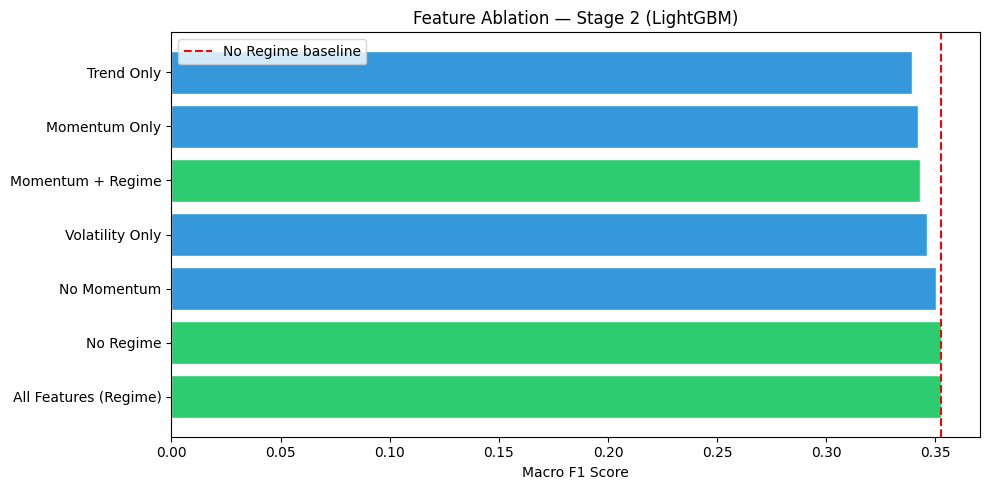

In [21]:
# Visualize ablation
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if 'Regime' in g or 'All' in g else '#3498db'
          for g in ablation_df['Feature Group']]
ax.barh(ablation_df['Feature Group'], ablation_df['Macro F1'], color=colors, edgecolor='white')
ax.axvline(ablation_df[ablation_df['Feature Group'] == 'No Regime']['Macro F1'].values[0],
           color='red', linestyle='--', lw=1.5, label='No Regime baseline')
ax.set_xlabel('Macro F1 Score')
ax.set_title('Feature Ablation — Stage 2 (LightGBM)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/trained/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Walk-Forward Cross-Validation

Time-series CV using `sklearn.TimeSeriesSplit`. Ensures no future data leaks into training at any fold.

In [22]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Use LightGBM as walk-forward model
X_wf = scaler_s2.fit_transform(df_s2[S2_FEATURES_REGIME].values)
y_wf = df_s2['signal'].values

wf_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_wf)):
    X_wf_tr, X_wf_te = X_wf[train_idx], X_wf[test_idx]
    y_wf_tr, y_wf_te = y_wf[train_idx], y_wf[test_idx]

    model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
    )
    model.fit(X_wf_tr, y_wf_tr)
    y_pred = model.predict(X_wf_te)

    wf_results.append({
        'Fold': fold + 1,
        'Train Size': len(train_idx),
        'Test Size': len(test_idx),
        'Accuracy': accuracy_score(y_wf_te, y_pred),
        'Macro F1': f1_score(y_wf_te, y_pred, average='macro'),
    })

wf_df = pd.DataFrame(wf_results)
print('=== Walk-Forward CV Results (LightGBM, Stage 2) ===')
print(wf_df.to_string(index=False))
print(f'\nMean Macro F1: {wf_df["Macro F1"].mean():.4f} ± {wf_df["Macro F1"].std():.4f}')

=== Walk-Forward CV Results (LightGBM, Stage 2) ===
 Fold  Train Size  Test Size  Accuracy  Macro F1
    1      198920     198916  0.363269  0.357795
    2      397836     198916  0.391773  0.388918
    3      596752     198916  0.371976  0.366241
    4      795668     198916  0.362525  0.352902
    5      994584     198916  0.363083  0.354829

Mean Macro F1: 0.3641 ± 0.0148


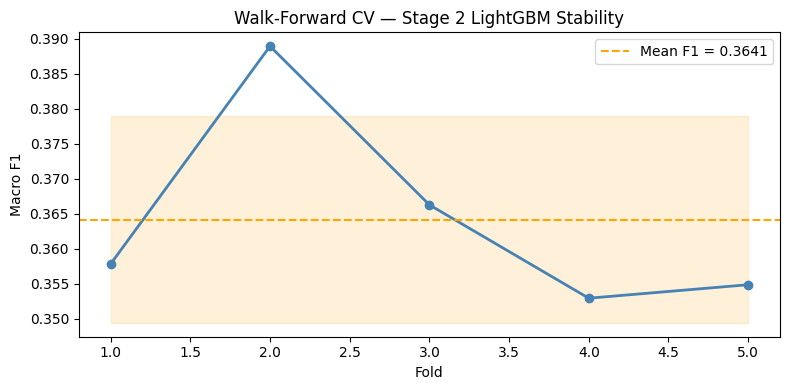

In [23]:
# Plot fold performance
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wf_df['Fold'], wf_df['Macro F1'], marker='o', color='steelblue', lw=2)
ax.axhline(wf_df['Macro F1'].mean(), color='orange', linestyle='--', lw=1.5, label=f'Mean F1 = {wf_df["Macro F1"].mean():.4f}')
ax.fill_between(wf_df['Fold'],
                wf_df['Macro F1'].mean() - wf_df['Macro F1'].std(),
                wf_df['Macro F1'].mean() + wf_df['Macro F1'].std(),
                alpha=0.15, color='orange')
ax.set_xlabel('Fold')
ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward CV — Stage 2 LightGBM Stability')
ax.legend()
plt.tight_layout()
plt.savefig('plots/trained/walk_forward_cv.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Final Comparative Evaluation — Stage 2

In [24]:
s2_results = [
    ('Logistic Regression (regime)', y_test_s2, y_pred_lr_s2),
    ('Logistic Regression (base)', y_test_s2, y_pred_lr_s2_base),
    ('Random Forest (regime)', y_test_s2, y_pred_rf_s2),
    ('Random Forest (base)', y_test_s2, y_pred_rf_s2_base),
    ('LightGBM (regime)', y_test_s2, y_pred_lgb_s2),
    ('LightGBM (base)', y_test_s2, y_pred_lgb_s2_base),
]

summary_s2 = pd.DataFrame([
    {
        'Model': name,
        'Has Regime': 'regime' in name,
        'Accuracy': accuracy_score(yt, yp),
        'Macro F1':  f1_score(yt, yp, average='macro'),
        'Weighted F1': f1_score(yt, yp, average='weighted'),
    }
    for name, yt, yp in s2_results
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('=== Stage 2 Final Model Comparison ===')
print(summary_s2.to_string(index=False))

=== Stage 2 Final Model Comparison ===
                       Model  Has Regime  Accuracy  Macro F1  Weighted F1
           LightGBM (regime)        True  0.363320  0.352321     0.352483
             LightGBM (base)       False  0.362808  0.350129     0.350200
      Random Forest (regime)        True  0.363198  0.349078     0.349263
        Random Forest (base)       False  0.362540  0.346402     0.346452
  Logistic Regression (base)       False  0.361542  0.341462     0.341683
Logistic Regression (regime)        True  0.360334  0.337719     0.337844


=== Regime Signal Impact ===
              Model  ΔMacro F1 (regime vs base)
Logistic Regression                   -0.003742
      Random Forest                    0.002676
           LightGBM                    0.002193


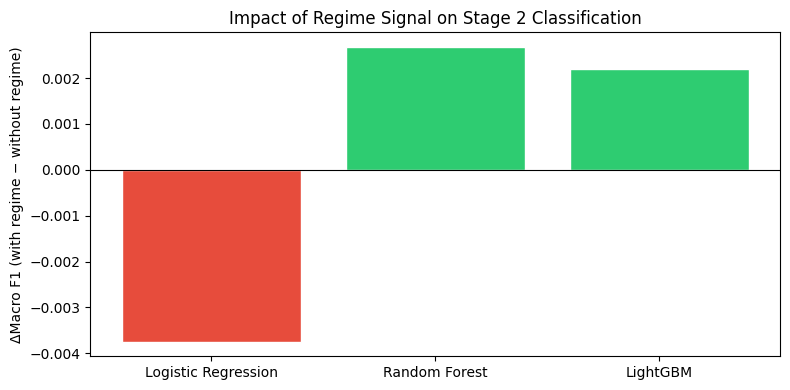

In [25]:
# Regime impact: delta between paired regime vs base models
regime_delta = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'ΔMacro F1 (regime vs base)': (
            f1_score(y_test_s2, y_pred_lr_s2, average='macro') -
            f1_score(y_test_s2, y_pred_lr_s2_base, average='macro')
        )
    },
    {
        'Model': 'Random Forest',
        'ΔMacro F1 (regime vs base)': (
            f1_score(y_test_s2, y_pred_rf_s2, average='macro') -
            f1_score(y_test_s2, y_pred_rf_s2_base, average='macro')
        )
    },
    {
        'Model': 'LightGBM',
        'ΔMacro F1 (regime vs base)': (
            f1_score(y_test_s2, y_pred_lgb_s2, average='macro') -
            f1_score(y_test_s2, y_pred_lgb_s2_base, average='macro')
        )
    },
])

print('=== Regime Signal Impact ===')
print(regime_delta.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in regime_delta['ΔMacro F1 (regime vs base)']]
ax.bar(regime_delta['Model'], regime_delta['ΔMacro F1 (regime vs base)'],
       color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔMacro F1 (with regime − without regime)')
ax.set_title('Impact of Regime Signal on Stage 2 Classification')
plt.tight_layout()
plt.savefig('plots/trained/regime_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Feature Importance — LightGBM Stage 2

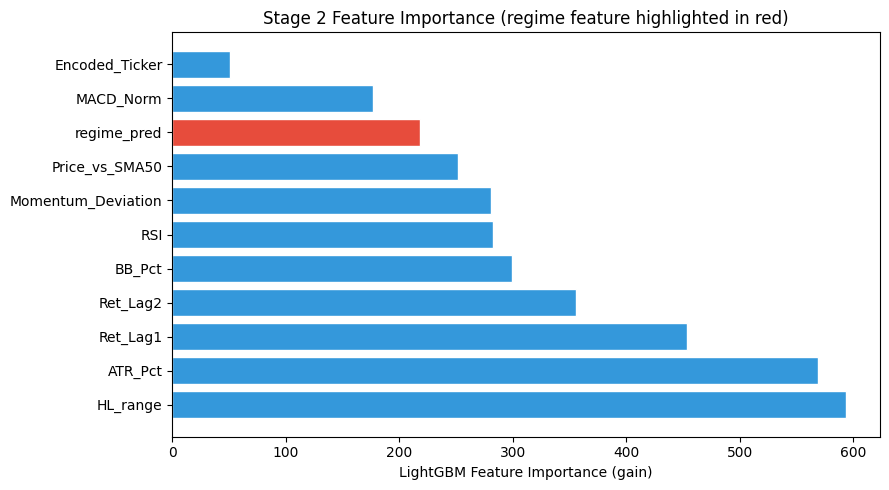

In [26]:
importance_df = pd.DataFrame({
    'Feature': S2_FEATURES_REGIME,
    'Importance': lgb_s2.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if f == 'regime_pred' else '#3498db' for f in importance_df['Feature']]
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='white')
ax.set_xlabel('LightGBM Feature Importance (gain)')
ax.set_title('Stage 2 Feature Importance (regime feature highlighted in red)')
plt.tight_layout()
plt.savefig('plots/trained/feature_importance_s2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Save Models & Results

In [28]:
import pickle, os

os.makedirs('results', exist_ok=True)

# Stage 1
with open('models/trained/lr_s1.pkl', 'wb') as f: pickle.dump(lr_s1, f)
with open('models/trained/rf_s1.pkl', 'wb') as f: pickle.dump(rf_s1, f)
with open('models/trained/lgb_s1.pkl', 'wb') as f: pickle.dump(lgb_s1, f)
with open('models/trained/scaler_s1.pkl', 'wb') as f: pickle.dump(scaler_s1, f)

# Stage 2
with open('models/trained/lr_s2.pkl', 'wb') as f: pickle.dump(lr_s2, f)
with open('models/trained/rf_s2.pkl', 'wb') as f: pickle.dump(rf_s2, f)
with open('models/trained/lgb_s2.pkl', 'wb') as f: pickle.dump(lgb_s2, f)
with open('models/trained/scaler_s2.pkl', 'wb') as f: pickle.dump(scaler_s2, f)

# Results
summary_s1.to_csv('results/stage1_model_comparison.csv', index=False)
summary_s2.to_csv('results/stage2_model_comparison.csv', index=False)
ablation_df.to_csv('results/ablation_study.csv', index=False)
wf_df.to_csv('results/walk_forward_cv.csv', index=False)
regime_delta.to_csv('results/regime_impact.csv', index=False)

print('All models and results saved.')

All models and results saved.


---
## Summary

| Component | Details |
|---|---|
| Stage 1 models | LR, RF, LightGBM — regime classification (Bullish/Bearish/High-Vol) |
| Stage 2 models | LR, RF, LightGBM — stock-level Buy/Hold/Sell |
| Evaluation | Accuracy, Macro F1, Weighted F1, confusion matrices |
| Ablation | 7 feature group configurations, regime vs no-regime delta |
| Validation | Walk-forward TimeSeriesSplit (5 folds) |
| Key question | Does regime signal improve Stage 2? → See `results/regime_impact.csv` |